# Notebook 03 - Baseline CNN Evaluation

**Project:** Image-Based Fruit Ripeness Classification  
**Student:** Corneliu Rosca | STU141830  
**Week:** 4

---

## Objective

Perform a formal evaluation of the trained Baseline CNN on the **held-out test set** (never seen during training). This notebook produces the 'official' reference figures for the report:

1. Loads the trained model `saved_models/baseline_best.h5`
2. Rebuilds the test split (same seed = same images as during training)
3. Runs inference on the test set
4. Computes accuracy, per-class precision/recall/F1, macro metrics
5. Generates a confusion matrix (count + normalised)
6. Generates one-vs-rest ROC curves with AUC
7. Prints a full classification report
8. Updates `results/results.csv` with the macro metrics

## Note on expected results

The Baseline CNN reached only ~12.7% validation accuracy (near the 11.1% random-guess level for 9 classes) due to severe overfitting on the small dataset. Test-set performance is therefore expected to be similarly low. This is the **documented reference point** against which MobileNetV2 transfer learning will be compared in Weeks 5–7.

## 1. Setup - imports and seeds

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add project root to path
sys.path.insert(0, str(Path(os.getcwd()).parent))

import tensorflow as tf
from src.utils import set_seeds, CLASS_NAMES, NUM_CLASSES, ensure_dirs
from src.data_pipeline import stratified_split, build_tf_dataset

set_seeds(42)
ensure_dirs('../results')

print(f'TensorFlow version: {tf.__version__}')
print(f'Classes: {NUM_CLASSES}')
print(f'Class names: {CLASS_NAMES}')

[utils] Seeds fixed to 42
TensorFlow version: 2.11.0
Classes: 9
Class names: ['apple_unripe', 'apple_ripe', 'apple_overripe', 'banana_unripe', 'banana_ripe', 'banana_overripe', 'pear_unripe', 'pear_ripe', 'pear_overripe']


## 2. Load the trained Baseline CNN

In [2]:
MODEL_PATH = '../saved_models/baseline_best.h5'

model = tf.keras.models.load_model(MODEL_PATH)
print(f'Model loaded from: {MODEL_PATH}')
print(f'Total parameters: {model.count_params():,}')

Model loaded from: ../saved_models/baseline_best.h5
Total parameters: 458,441


## 3. Rebuild the test split

Using the **same seed (42)** guarantees the same train/val/test partitioning as during training. The test set was never seen by the model.

In [3]:
_, _, test_samples = stratified_split('../dataset', seed=42)

test_ds = build_tf_dataset(
    test_samples,
    batch_size=32,
    augment=False,   # NO augmentation on test set
    shuffle=False    # NO shuffle, so order matches labels
)

print(f'Test set size: {len(test_samples)} images')

# Per-class test counts
from collections import Counter
test_counts = Counter([CLASS_NAMES[idx] for _, idx in test_samples])
for cls in CLASS_NAMES:
    print(f'  {cls:<22}: {test_counts.get(cls, 0)} test images')

2026-06-01 14:47:55 [INFO] data_pipeline:   apple_unripe          :  35 train |   7 val |   8 test
2026-06-01 14:47:55 [INFO] data_pipeline:   apple_ripe            :  35 train |   7 val |   8 test
2026-06-01 14:47:55 [INFO] data_pipeline:   apple_overripe        :  35 train |   7 val |   8 test
2026-06-01 14:47:55 [INFO] data_pipeline:   banana_unripe         :  35 train |   7 val |   8 test
2026-06-01 14:47:55 [INFO] data_pipeline:   banana_ripe           :  35 train |   7 val |   8 test
2026-06-01 14:47:55 [INFO] data_pipeline:   banana_overripe       :  35 train |   7 val |   8 test
2026-06-01 14:47:55 [INFO] data_pipeline:   pear_unripe           :  35 train |   7 val |   8 test
2026-06-01 14:47:55 [INFO] data_pipeline:   pear_ripe             :  35 train |   7 val |   8 test
2026-06-01 14:47:55 [INFO] data_pipeline:   pear_overripe         :  35 train |   7 val |   8 test


Test set size: 72 images
  apple_unripe          : 8 test images
  apple_ripe            : 8 test images
  apple_overripe        : 8 test images
  banana_unripe         : 8 test images
  banana_ripe           : 8 test images
  banana_overripe       : 8 test images
  pear_unripe           : 8 test images
  pear_ripe             : 8 test images
  pear_overripe         : 8 test images


## 4. Run inference on the test set

In [4]:
y_true = []
y_scores = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_scores.append(preds)
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_scores = np.vstack(y_scores)
y_pred   = np.argmax(y_scores, axis=1)
y_true   = np.array(y_true)

print(f'Predictions complete.')
print(f'  y_true shape:   {y_true.shape}')
print(f'  y_pred shape:   {y_pred.shape}')
print(f'  y_scores shape: {y_scores.shape}')

Predictions complete.
  y_true shape:   (72,)
  y_pred shape:   (72,)
  y_scores shape: (72, 9)


## 5. Compute metrics

In [5]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)

accuracy        = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall_macro    = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1_macro        = f1_score(y_true, y_pred, average='macro', zero_division=0)

print('=' * 50)
print('  BASELINE CNN - TEST SET METRICS')
print('=' * 50)
print(f'  Test accuracy        : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision (macro)    : {precision_macro:.4f}')
print(f'  Recall (macro)       : {recall_macro:.4f}')
print(f'  F1-score (macro)     : {f1_macro:.4f}')
print(f'  Random-guess baseline: {1/NUM_CLASSES:.4f}  (11.11%)')
print('=' * 50)

  BASELINE CNN - TEST SET METRICS
  Test accuracy        : 0.0972  (9.72%)
  Precision (macro)    : 0.0561
  Recall (macro)       : 0.0972
  F1-score (macro)     : 0.0511
  Random-guess baseline: 0.1111  (11.11%)


## 6. Full classification report (per-class metrics)

In [6]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    zero_division=0,
    digits=4
)
print(report)

# Save to file for the report appendix
with open('../results/classification_report_baseline.txt', 'w') as f:
    f.write('BASELINE CNN - TEST SET CLASSIFICATION REPORT\n')
    f.write('=' * 55 + '\n\n')
    f.write(report)
print('\nSaved → results/classification_report_baseline.txt')

                 precision    recall  f1-score   support

   apple_unripe     0.3333    0.1250    0.1818         8
     apple_ripe     0.1026    0.5000    0.1702         8
 apple_overripe     0.0690    0.2500    0.1081         8
  banana_unripe     0.0000    0.0000    0.0000         8
    banana_ripe     0.0000    0.0000    0.0000         8
banana_overripe     0.0000    0.0000    0.0000         8
    pear_unripe     0.0000    0.0000    0.0000         8
      pear_ripe     0.0000    0.0000    0.0000         8
  pear_overripe     0.0000    0.0000    0.0000         8

       accuracy                         0.0972        72
      macro avg     0.0561    0.0972    0.0511        72
   weighted avg     0.0561    0.0972    0.0511        72


Saved → results/classification_report_baseline.txt


## 7. Confusion matrix (count + normalised)

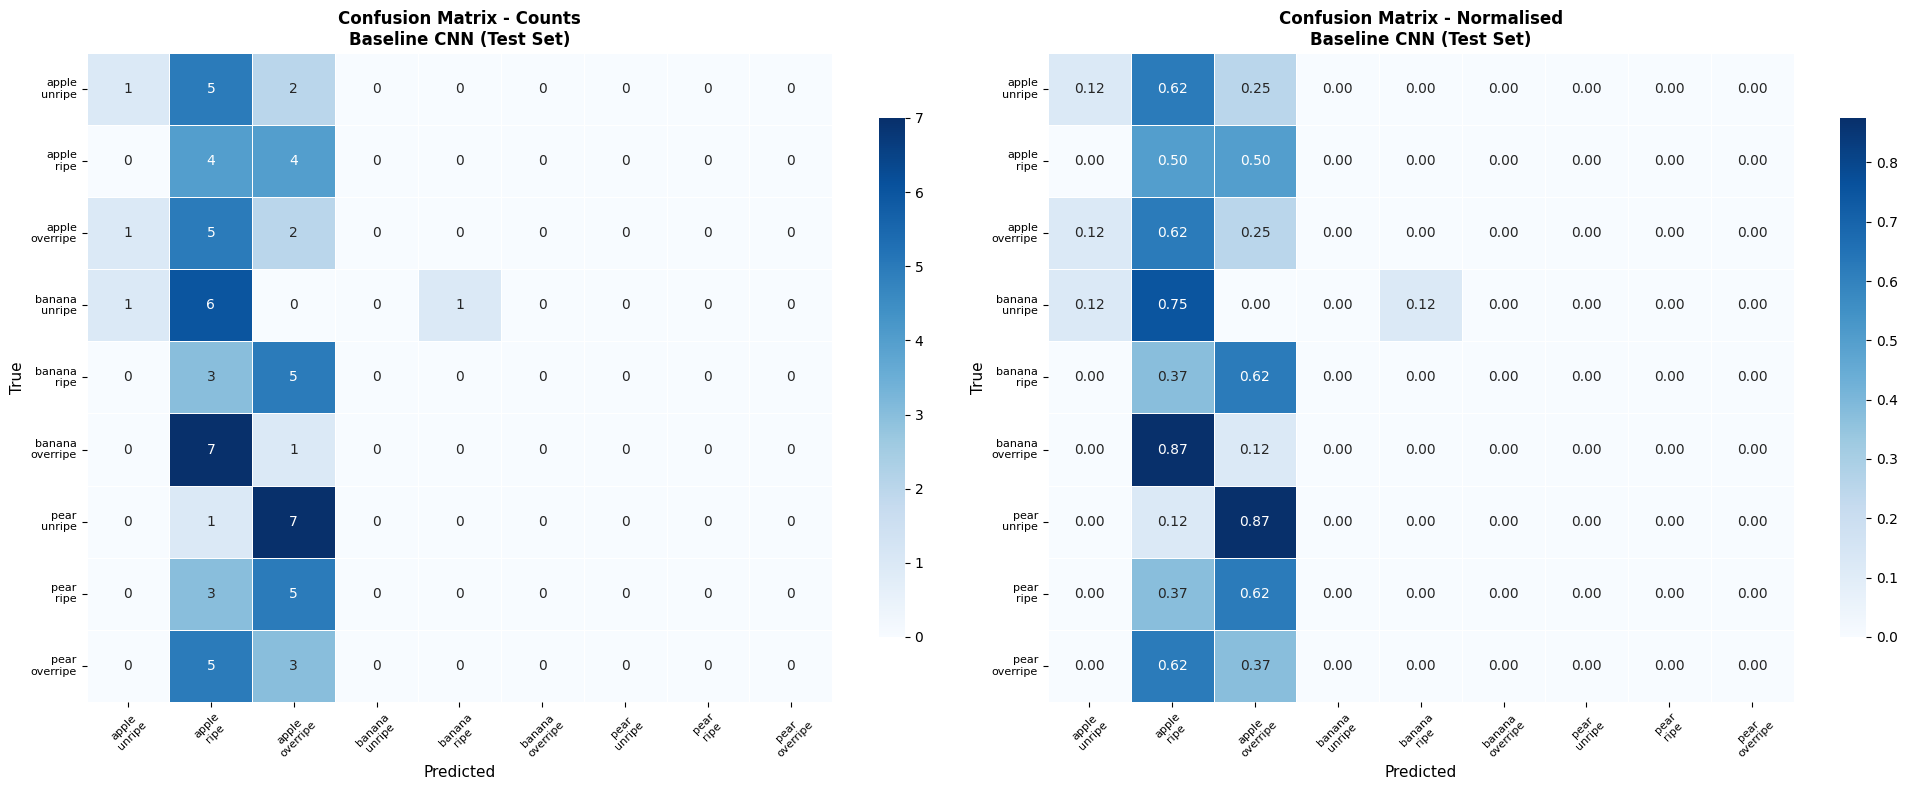

Saved → results/confusion_matrix_baseline.png


In [7]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

short_names = [c.replace('_', '\n') for c in CLASS_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Count
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            ax=axes[0], linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[0].set_title('Confusion Matrix - Counts\nBaseline CNN (Test Set)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('True', fontsize=11)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# Normalised
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            ax=axes[1], linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[1].set_title('Confusion Matrix - Normalised\nBaseline CNN (Test Set)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('True', fontsize=11)
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig('../results/confusion_matrix_baseline.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → results/confusion_matrix_baseline.png')

## 8. ROC curves (one-vs-rest)

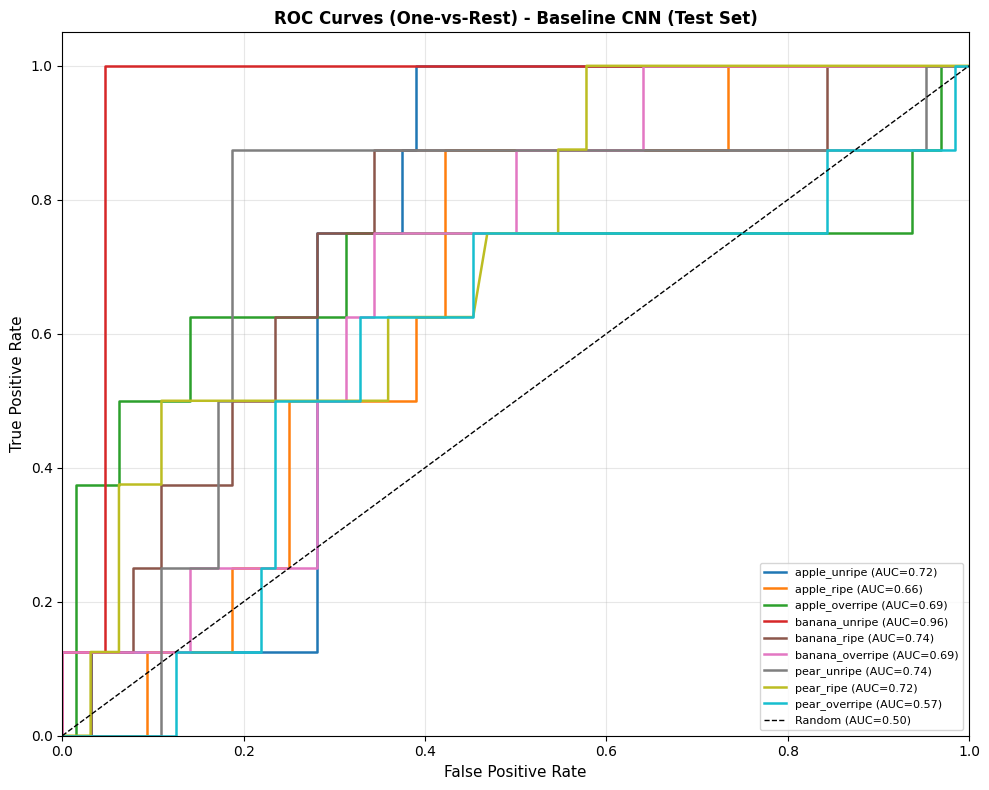

Saved → results/roc_curves_baseline.png
Mean AUC across classes: 0.7212


In [8]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

auc_values = {}
for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    if y_bin[:, i].sum() > 0:  # class present in test set
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        auc_values[cls] = roc_auc
        ax.plot(fpr, tpr, color=color, lw=1.8,
                label=f'{cls} (AUC={roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.50)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves (One-vs-Rest) - Baseline CNN (Test Set)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/roc_curves_baseline.png', dpi=120, bbox_inches='tight')
plt.show()

mean_auc = np.mean(list(auc_values.values()))
print(f'Saved → results/roc_curves_baseline.png')
print(f'Mean AUC across classes: {mean_auc:.4f}')

## 9. Update results.csv with macro metrics

In [9]:
results_path = Path('../results/results.csv')

eval_row = {
    'model':           'baseline',
    'epoch':           'test_eval',
    'val_loss':        'N/A',
    'val_acc':         round(accuracy, 4),
    'precision_macro': round(precision_macro, 4),
    'recall_macro':    round(recall_macro, 4),
    'f1_macro':        round(f1_macro, 4),
}

if results_path.exists():
    df = pd.read_csv(results_path)
    # Remove any previous test_eval row for baseline
    df = df[~((df['model'] == 'baseline') & (df['epoch'].astype(str) == 'test_eval'))]
    df = pd.concat([df, pd.DataFrame([eval_row])], ignore_index=True)
else:
    df = pd.DataFrame([eval_row])

df.to_csv(results_path, index=False)
print('Updated → results/results.csv')
df

Updated → results/results.csv


,model,epoch,val_loss,val_acc,precision_macro,recall_macro,f1_macro
0,baseline,3,2.2414,0.1270,NaN,NaN,NaN
1,baseline,test_eval,N/A,0.0972,0.0561,0.0972,0.0511


## 10. Summary and next steps

**Completed in this notebook:**

| Step | Output |
|------|--------|
| Test set inference | y_true, y_pred, y_scores |
| Accuracy + macro precision/recall/F1 | printed summary |
| Full classification report | `results/classification_report_baseline.txt` |
| Confusion matrix (count + normalised) | `results/confusion_matrix_baseline.png` |
| ROC curves (one-vs-rest) | `results/roc_curves_baseline.png` |
| Macro metrics added to results | `results/results.csv` |

**Next step:** Week 5 - MobileNetV2 Phase 1 (head-only transfer learning), expected to substantially outperform the Baseline CNN documented here.